In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns',None)

In [3]:
df=pd.read_csv('C:/Users/8429s/OneDrive/Desktop/Placement/Projects/Real Estate Price Prediction and Recommendation System/Data_Clean/flats_and_house_v2.csv').drop_duplicates()

In [5]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,independent,sector 4,0.58,86567.0,67.0,Plot area 67(6.22 sq.m.),2,2,1,2.0,West,Moderately Old,NaN,67.0,NaN,0,0,0,1,1,1,7
1,flat,emaar mgf palm hills,sector 77,1.25,8620.0,1450.0,Super Built up area 1450(134.71 sq.m.)Carpet a...,3,4,3,3.0,North,Relatively New,1450.0,NaN,1177.0,1,1,0,0,0,1,49
2,flat,chd avenue,sector 71,1.00,6734.0,1485.0,Super Built up area 1485(137.96 sq.m.),3,3,3+,3.0,North,Relatively New,1485.0,NaN,NaN,0,0,0,0,0,2,7
3,flat,ild grand,sector 37c,1.20,6593.0,1820.0,Super Built up area 1820(169.08 sq.m.),3,3,3,7.0,NaN,Under Construction,1820.0,NaN,NaN,0,0,0,0,0,1,24
4,flat,dlf the ultima,sector 81,2.20,10461.0,2103.0,Super Built up area 2103(195.38 sq.m.)Built Up...,3,3,3+,5.0,East,Relatively New,2103.0,1570.0,1257.0,1,1,0,1,1,0,49


In [6]:
df.shape

(3677, 23)

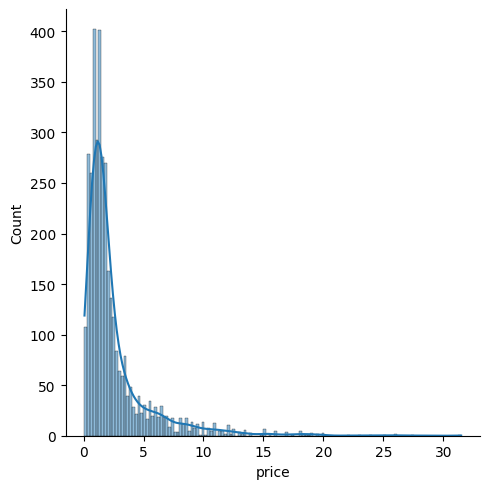

In [9]:
sns.displot(df['price'],kde=True)

<Axes: ylabel='price'>

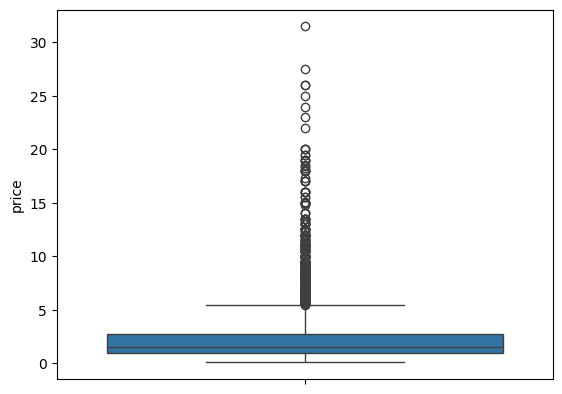

In [10]:
sns.boxplot(df['price'])

In [12]:
Q1=df['price'].quantile(0.25)
Q3=df['price'].quantile(0.75)

IQR=Q3-Q1

lower_bound=Q1 - 1.5*IQR
upper_bound=Q3 + 1.5*IQR

outliers = df[(df['price']<lower_bound) | (df['price']>upper_bound)]

num_outliers = outliers.shape[0]
outliers_price_stats = outliers['price'].describe()

num_outliers,outliers_price_stats

(425,
 count    425.000000
 mean       9.235624
 std        4.065259
 min        5.460000
 25%        6.460000
 50%        8.000000
 75%       10.750000
 max       31.500000
 Name: price, dtype: float64)

In [13]:
outliers.sort_values('price',ascending=False).head(20)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2294,house,arjun marg/ sector- 26 phase- 1/ golf course road,sector 26,31.50,35000.0,9000.0,Plot area 1000(836.13 sq.m.),7,9,3+,3.0,North-East,Moderately Old,NaN,9000.0,NaN,1,1,1,1,0,0,74
1774,house,independent,sector 43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,NaN,11286.0,NaN,1,1,0,1,1,2,42
2398,house,independent,sector 26,26.00,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,4.0,North-West,New Property,NaN,400.0,350.0,1,1,1,1,0,2,72
3464,house,dlf city plots,sector 26,26.00,57206.0,4545.0,Plot area 505(422.24 sq.m.),6,7,3+,2.0,North-East,New Property,NaN,4545.0,NaN,1,1,0,1,1,2,138
2901,house,suncity township,sector 54,25.00,31111.0,8036.0,Plot area 1000(836.13 sq.m.),4,4,3+,2.0,North,Moderately Old,NaN,1000.0,NaN,1,1,1,1,0,1,0
1692,house,emaar the palm springs,sector 54,24.00,600000.0,400.0,Plot area 400(37.16 sq.m.),5,5,2,1.0,North-East,Old Property,NaN,400.0,NaN,1,1,0,1,0,2,122
3195,house,independent,sector 26,23.00,25556.0,9000.0,Plot area 1000(836.13 sq.m.),4,4,3+,2.0,South-West,Relatively New,NaN,9000.0,NaN,1,1,1,1,0,2,145
3353,house,vipul tatvam villa,sector 48,22.00,26667.0,8250.0,Plot area 1000(836.13 sq.m.),5,6,3,3.0,NaN,Moderately Old,NaN,1000.0,NaN,0,1,0,0,0,1,54
259,house,independent,sector 26,20.00,44444.0,4500.0,Plot area 500(418.06 sq.m.),5,7,3+,3.0,West,Relatively New,NaN,4500.0,NaN,0,1,0,1,0,0,97
2863,house,dlf city plots,sector 26,20.00,44265.0,4518.0,Plot area 502(419.74 sq.m.),16,20,3+,4.0,North-East,New Property,NaN,4518.0,NaN,1,1,1,1,0,2,153


Some price values are really outlier and some are not oulier

### Price_per_sqft

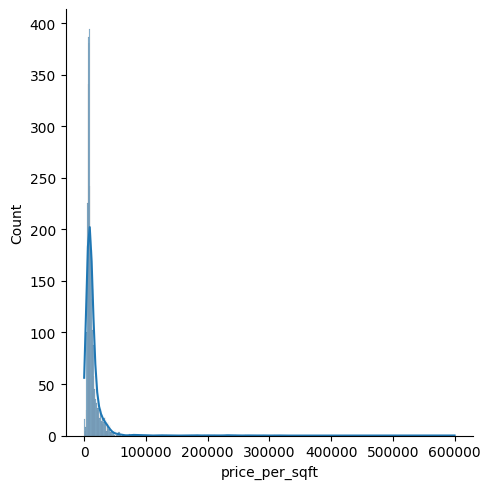

In [14]:
sns.displot(df['price_per_sqft'],kde=True)

<Axes: xlabel='price_per_sqft'>

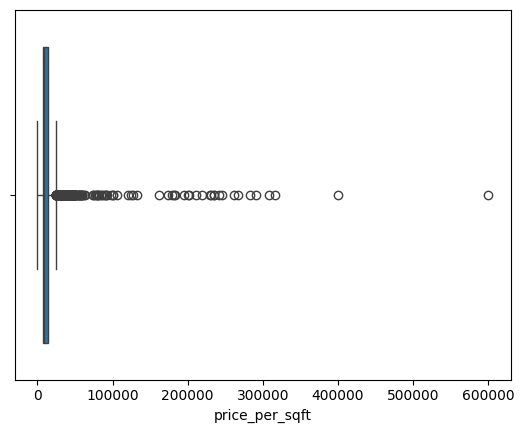

In [15]:
sns.boxplot(x=df['price_per_sqft'])

In [16]:
# Calculate the IQR for the 'price' column
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_sqft = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers_sqft.shape[0]
outliers_sqft_stats = outliers_sqft['price_per_sqft'].describe()


In [17]:
outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)

C:\Users\8429s\AppData\Local\Temp\ipykernel_6252\205471443.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)


In [18]:
outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])

C:\Users\8429s\AppData\Local\Temp\ipykernel_6252\3686006548.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])


In [19]:
outliers_sqft['price_per_sqft'].describe()

count      354.000000
mean     29357.906780
std      12403.077309
min       2723.000000
25%      25562.000000
50%      29870.500000
75%      35549.500000
max      82540.000000
Name: price_per_sqft, dtype: float64

In [20]:
df.update(outliers_sqft)

C:\Users\8429s\AppData\Local\Temp\ipykernel_6252\3497786636.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'],kde=True)


<Axes: xlabel='price_per_sqft', ylabel='Density'>

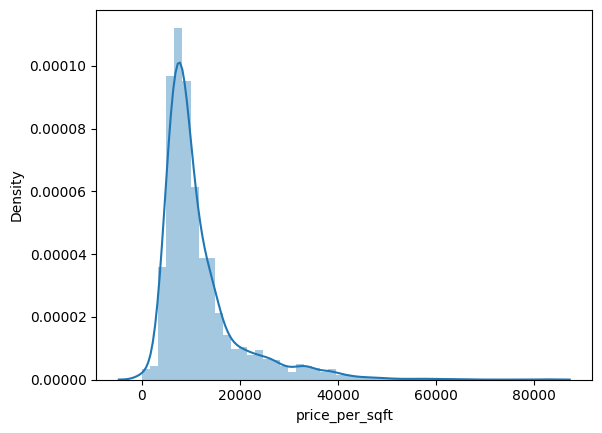

In [21]:
sns.distplot(df['price_per_sqft'],kde=True)

<Axes: xlabel='price_per_sqft'>

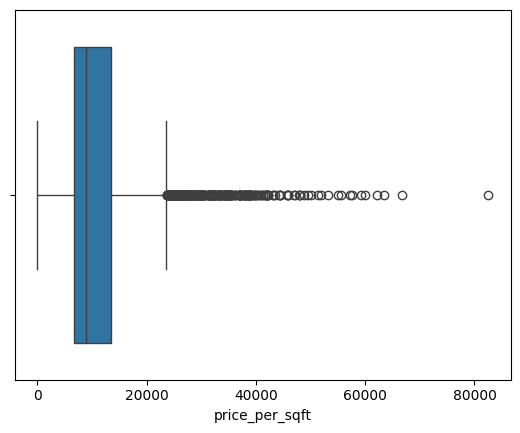

In [22]:
sns.boxplot(x=df['price_per_sqft'])

In [23]:
df[df['price_per_sqft']>50000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
687,house,independent,sector 25,16.00,59259.0,2700.0,Plot area 350(292.64 sq.m.)Built Up area: 325 ...,16,16,3+,4.0,West,New Property,NaN,325.0,300.0,1,1,1,1,0,2,72
1046,house,project housing board colony,sector 31,8.00,63492.0,1260.0,Built Up area: 140 (117.06 sq.m.),2,1,0,1.0,NaN,Undefined,NaN,140.0,NaN,0,0,0,0,0,1,0
1252,house,cloudnine cottages,sohna road road,5.50,55000.0,1000.0,Plot area 1000(92.9 sq.m.),3,3,0,1.0,NaN,Moderately Old,NaN,1000.0,NaN,0,0,0,0,0,1,0
1453,house,malibu towne,sector 47,8.50,53125.0,1600.0,Built Up area: 1600 (148.64 sq.m.),12,12,3+,4.0,North,New Property,NaN,1600.0,NaN,0,0,0,0,0,2,99
1574,house,independent,sector 26,14.75,51864.0,2844.0,Plot area 316(264.22 sq.m.),16,20,3+,4.0,East,New Property,NaN,2844.0,NaN,1,1,1,1,0,2,153
1668,house,nul,sector 28,12.50,51440.0,2430.0,Plot area 270(225.75 sq.m.),16,17,3+,4.0,South,Relatively New,NaN,2430.0,NaN,1,1,0,1,1,0,137
1692,house,emaar the palm springs,sector 54,24.00,66667.0,3600.0,Plot area 400(37.16 sq.m.),5,5,2,1.0,North-East,Old Property,NaN,400.0,NaN,1,1,0,1,0,2,122
2159,house,emaar mgf marbella,sector 66,18.00,55556.0,3240.0,Plot area 360(301.01 sq.m.),4,4,3+,3.0,East,Moderately Old,NaN,3240.0,NaN,1,1,0,1,0,0,75
2209,house,unitech escape,sector 50,10.80,60000.0,1800.0,Plot area 290(242.48 sq.m.)Built Up area: 250 ...,4,4,3,2.0,North,Relatively New,NaN,250.0,200.0,1,1,1,1,0,2,103
2398,house,independent,sector 26,26.00,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,4.0,North-West,New Property,NaN,400.0,350.0,1,1,1,1,0,2,72


In [24]:
df = df[df['price_per_sqft'] <= 50000]

<Axes: xlabel='price_per_sqft'>

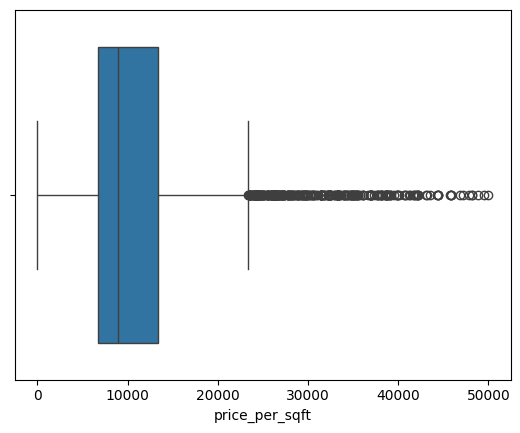

In [25]:
sns.boxplot(x=df['price_per_sqft'])

## Area

C:\Users\8429s\AppData\Local\Temp\ipykernel_6252\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

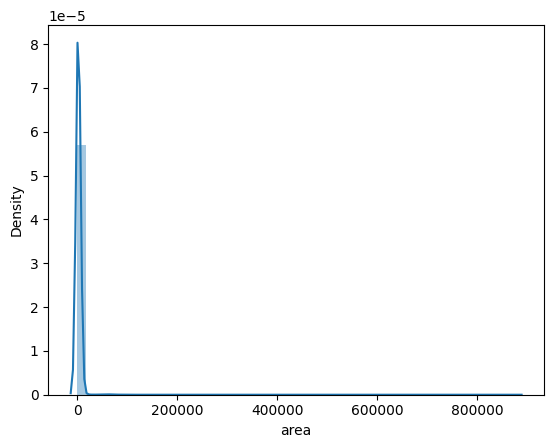

In [26]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

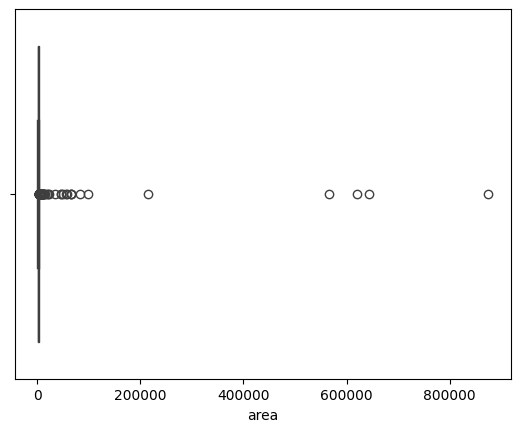

In [27]:
sns.boxplot(x=df['area'])

In [28]:
df[df['area']>100000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1031,house,independent,sector 50,5.00,232.0,215517.0,Plot area 2(1011.71 sq.m.),6,5,3+,2.0,NaN,New Property,NaN,2.0,NaN,1,1,0,1,1,2,0
1555,flat,signature the roselia,sector 95,0.45,7.0,642857.0,Carpet area: 569243 (52884.41 sq.m.),2,2,2,2.0,South-West,New Property,NaN,NaN,569243.0,0,0,0,0,0,1,76
1753,flat,ramsons kshitij,sector 95,0.31,5.0,620000.0,Carpet area: 607936 (56479.1 sq.m.),2,2,1,1.0,North-East,Relatively New,NaN,NaN,607936.0,1,0,0,0,1,1,65
3649,flat,hcbs sports ville,sohna road,0.35,4.0,875000.0,Built Up area: 737147 (68483.2 sq.m.),2,2,2,8.0,NaN,Relatively New,NaN,737147.0,NaN,0,0,0,0,0,0,44
3651,flat,signature global solera 2,sector 107,0.51,9.0,566667.0,Carpet area: 514396 (47788.95 sq.m.),2,2,1,3.0,North,New Property,NaN,NaN,514396.0,0,0,0,0,0,1,44


In [29]:
df=df[df['area']<100000]

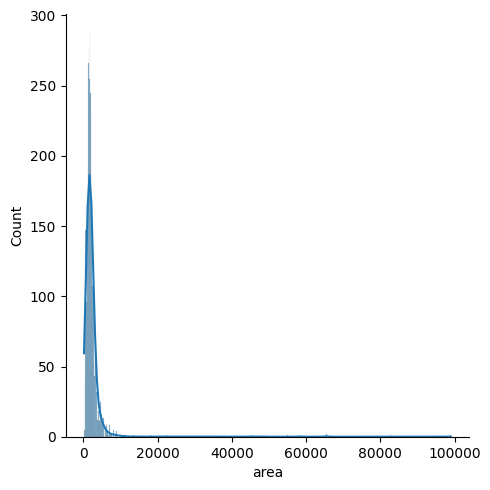

In [30]:
sns.displot(df['area'],kde=True)

<Axes: xlabel='area'>

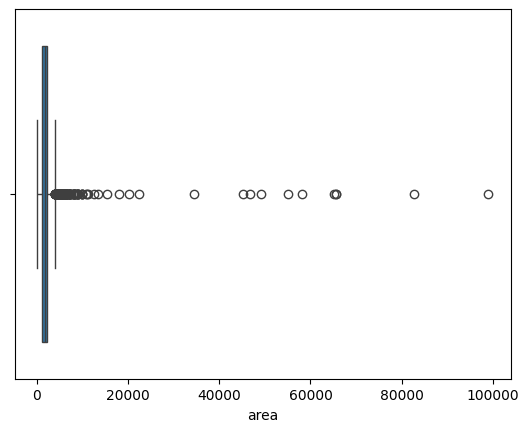

In [31]:
sns.boxplot(x=df['area'])

In [33]:
df[df['area'] > 10000].sort_values('area',ascending=False).index

Index([2501, 1232,  323,  951, 3173, 2635, 2790,  993, 3254,  587, 1336, 2552,
       2382, 1144, 1058, 2957,  653, 1774, 1482, 3472],
      dtype='int64')

In [34]:
df.drop(index=[2501, 1232,  323,  951, 3173, 2635, 2790,  993, 3254,  587, 1336, 2552,
       2382, 1144, 1058, 2957,  653, 1774, 1482, 3472], inplace=True)

C:\Users\8429s\AppData\Local\Temp\ipykernel_6252\2026402244.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df['area'])


<Axes: ylabel='Density'>

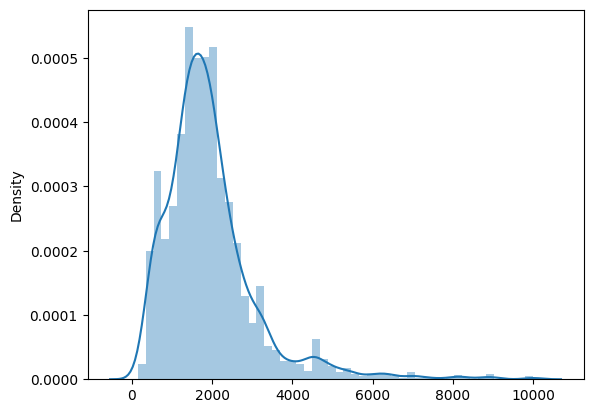

In [35]:
sns.distplot(x=df['area'])

<Axes: xlabel='area'>

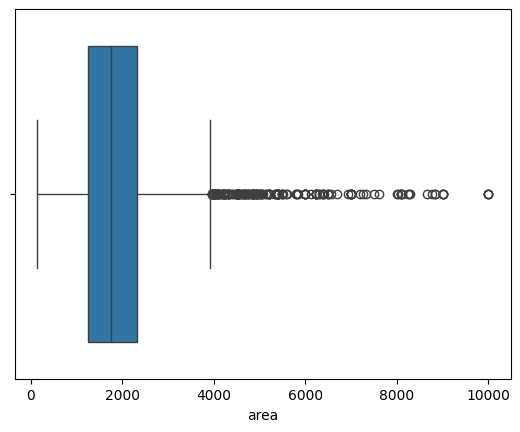

In [36]:
sns.boxplot(x=df['area'])

In [37]:
df['area'].describe()

count     3622.000000
mean      1940.314743
std       1183.806748
min        145.000000
25%       1260.000000
50%       1745.000000
75%       2323.250000
max      10000.000000
Name: area, dtype: float64

### BedRoom

C:\Users\8429s\AppData\Local\Temp\ipykernel_6252\1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

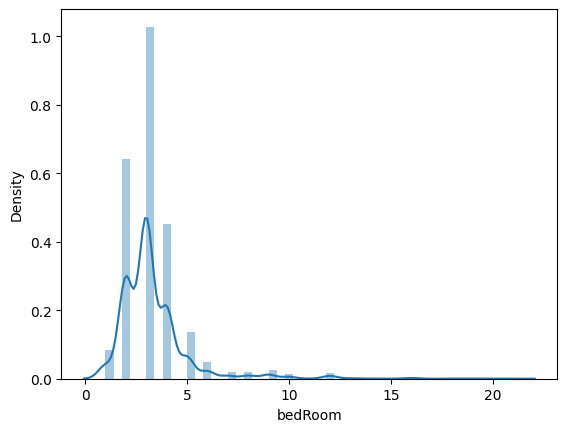

In [38]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

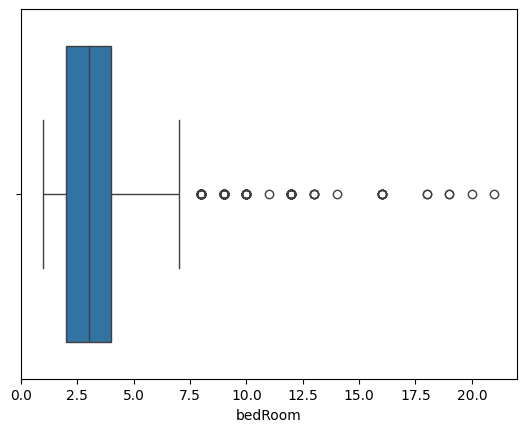

In [39]:
sns.boxplot(x=df['bedRoom'])

In [40]:
df['bedRoom'].describe()

count    3622.000000
mean        3.324682
std         1.818935
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        21.000000
Name: bedRoom, dtype: float64

In [41]:
df[df['bedRoom'] > 10].sort_values('bedRoom',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
980,house,independent,sector 54,5.00,43066.0,1161.0,Plot area 129(107.86 sq.m.),21,21,3+,5.0,North,Relatively New,NaN,1161.0,NaN,0,1,0,0,0,0,49
1909,house,independent,sector 43,4.50,39062.0,1152.0,Plot area 128(107.02 sq.m.),20,20,3+,4.0,East,Relatively New,NaN,1152.0,NaN,0,1,0,0,0,0,22
898,house,independent,sector 17a,3.87,5160.0,7500.0,Plot area 1623(150.78 sq.m.)Built Up area: 750...,19,17,3+,5.0,North-West,Relatively New,NaN,7500.0,NaN,1,0,1,0,0,1,68
3114,house,independent,sector 17a,3.93,24214.0,1623.0,Plot area 1623(150.78 sq.m.)Built Up area: 162...,19,17,3,4.0,North-West,Relatively New,NaN,1622.0,NaN,1,1,1,1,0,1,74
592,house,independent,sector 54,5.50,38194.0,1440.0,Plot area 160(133.78 sq.m.),18,18,3+,4.0,South-West,Relatively New,NaN,1440.0,NaN,0,1,0,0,0,0,70
2571,house,private house,sector 55,7.05,46906.0,1503.0,Plot area 167(139.63 sq.m.),18,18,3+,4.0,North-East,Relatively New,NaN,1503.0,NaN,0,0,0,0,1,0,57
1204,house,luxury dlf city floors,sector 26,20.00,48888.0,4091.0,Plot area 500(418.06 sq.m.),16,16,3+,4.0,NaN,New Property,NaN,500.0,NaN,0,1,0,0,0,2,31
3061,house,independent,sector 43,13.50,50000.0,2700.0,Plot area 300(250.84 sq.m.),16,16,3+,4.0,North-West,Relatively New,NaN,2700.0,NaN,1,1,0,1,1,1,41
2863,house,dlf city plots,sector 26,20.00,44267.0,4518.0,Plot area 502(419.74 sq.m.),16,20,3+,4.0,North-East,New Property,NaN,4518.0,NaN,1,1,1,1,0,2,153
1955,house,independent,sector 56,12.39,45889.0,2700.0,Plot area 300(250.84 sq.m.),16,18,3+,4.0,North-East,New Property,NaN,2700.0,NaN,0,1,0,1,0,2,49


In [42]:
df = df[df['bedRoom'] <= 10]

In [43]:
df.shape

(3577, 23)

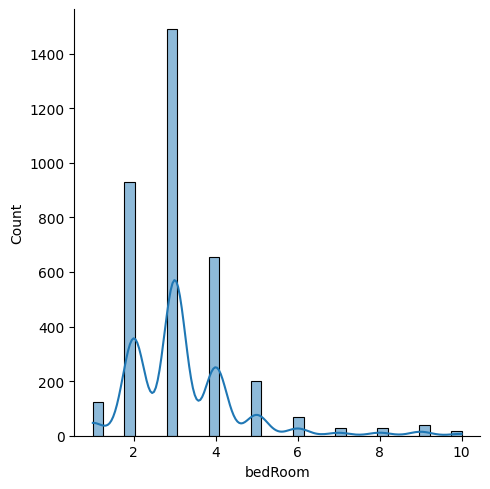

In [47]:
sns.displot(x=df['bedRoom'],kde=True)

<Axes: xlabel='bedRoom'>

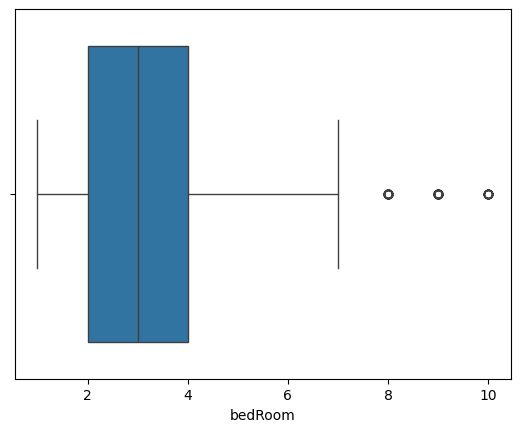

In [48]:
sns.boxplot(x=df['bedRoom'])

In [49]:
df['bedRoom'].describe()

count    3577.000000
mean        3.194297
std         1.376737
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: bedRoom, dtype: float64

### Bathroom

C:\Users\8429s\AppData\Local\Temp\ipykernel_6252\593171972.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df['bathroom'])


<Axes: ylabel='Density'>

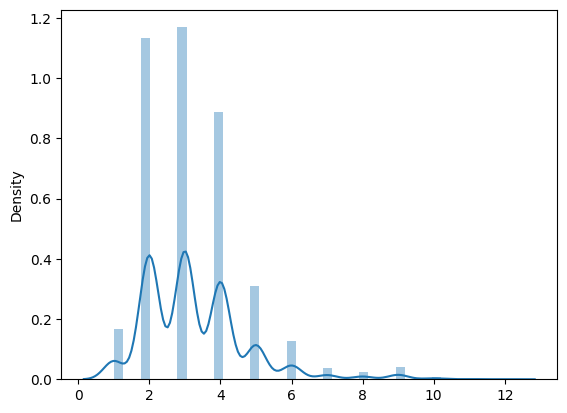

In [50]:
sns.distplot(x=df['bathroom'])

<Axes: xlabel='bathroom'>

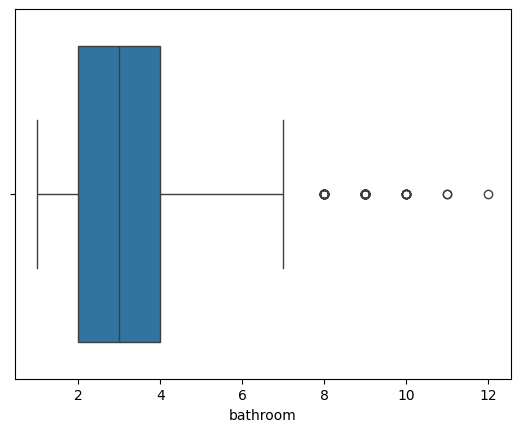

In [51]:
sns.boxplot(x=df['bathroom'])

In [52]:
df[df['bathroom'] > 10].sort_values('bathroom',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
153,house,adani brahma samsara,sector 60,18.02,28200.0,6390.0,Built Up area: 6390 (593.65 sq.m.),9,12,3+,3.0,North-East,Relatively New,NaN,6390.0,NaN,0,1,0,0,0,2,146
1351,house,independent,sector 24,11.00,28902.0,3806.0,Plot area 3806.45(353.63 sq.m.)Built Up area: ...,8,11,3+,3.0,East,Old Property,NaN,5000.0,NaN,1,1,0,1,1,2,39
3233,house,independent,sector 39,7.00,10000.0,7000.0,Plot area 350(32.52 sq.m.)Built Up area: 7000 ...,10,11,3+,4.0,South-East,Relatively New,NaN,7000.0,NaN,0,0,0,1,0,2,38


In [53]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,independent,sector 4,0.58,9619.0,603.0,Plot area 67(6.22 sq.m.),2,2,1,2.0,West,Moderately Old,NaN,67.0,NaN,0,0,0,1,1,1,7
1,flat,emaar mgf palm hills,sector 77,1.25,8620.0,1450.0,Super Built up area 1450(134.71 sq.m.)Carpet a...,3,4,3,3.0,North,Relatively New,1450.0,NaN,1177.0,1,1,0,0,0,1,49
2,flat,chd avenue,sector 71,1.00,6734.0,1485.0,Super Built up area 1485(137.96 sq.m.),3,3,3+,3.0,North,Relatively New,1485.0,NaN,NaN,0,0,0,0,0,2,7
3,flat,ild grand,sector 37c,1.20,6593.0,1820.0,Super Built up area 1820(169.08 sq.m.),3,3,3,7.0,NaN,Under Construction,1820.0,NaN,NaN,0,0,0,0,0,1,24
4,flat,dlf the ultima,sector 81,2.20,10461.0,2103.0,Super Built up area 2103(195.38 sq.m.)Built Up...,3,3,3+,5.0,East,Relatively New,2103.0,1570.0,1257.0,1,1,0,1,1,0,49


### Super Built up area

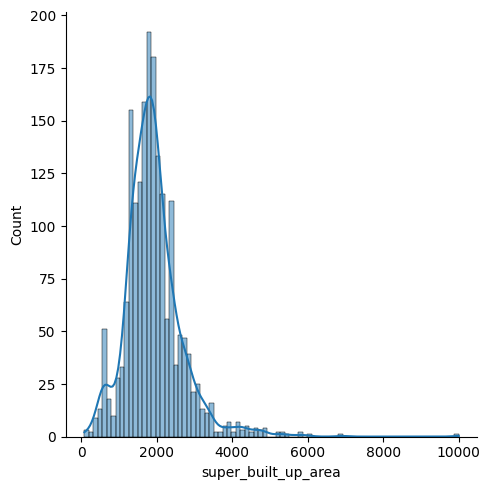

In [54]:
sns.displot(df['super_built_up_area'],kde=True)

<Axes: xlabel='super_built_up_area'>

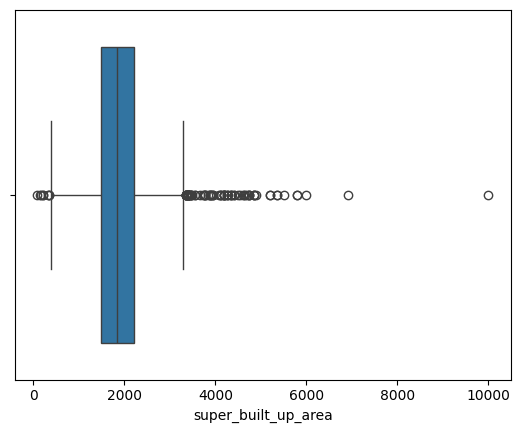

In [55]:
sns.boxplot(x=df['super_built_up_area'])

In [56]:
df['super_built_up_area'].describe()

count     1875.000000
mean      1925.237627
std        764.172177
min         89.000000
25%       1479.500000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

In [57]:
df[df['super_built_up_area'] > 6000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
339,flat,krrish provence estate,gwal pahari,7.5,7500.0,10000.0,Super Built up area 10000(929.03 sq.m.),5,6,3+,23.0,North-East,Relatively New,10000.0,NaN,NaN,0,1,0,1,1,1,49
1667,flat,bestech park view grand spa,sector 81,4.7,6786.0,6926.0,Super Built up area 6926(643.45 sq.m.),4,4,3+,19.0,North,Relatively New,6926.0,NaN,NaN,0,1,0,0,0,2,140


C:\Users\8429s\AppData\Local\Temp\ipykernel_6252\3494228458.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['built_up_area'])


<Axes: xlabel='built_up_area', ylabel='Density'>

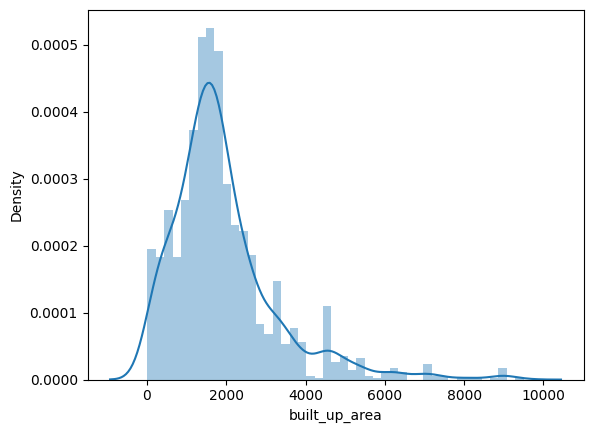

In [58]:
sns.distplot(df['built_up_area'])

<Axes: ylabel='built_up_area'>

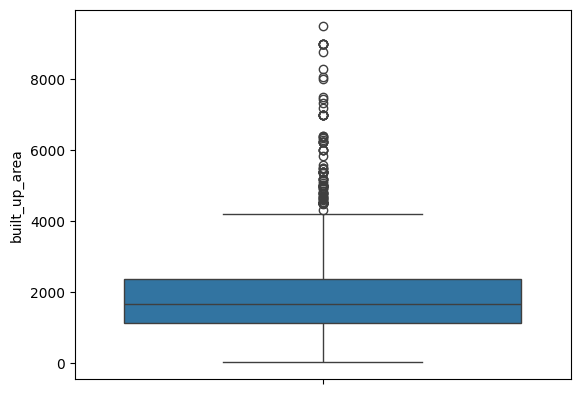

In [60]:
sns.boxplot(df['built_up_area'])

### carpet area

C:\Users\8429s\AppData\Local\Temp\ipykernel_6252\1487170794.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df['carpet_area'])


<Axes: ylabel='Density'>

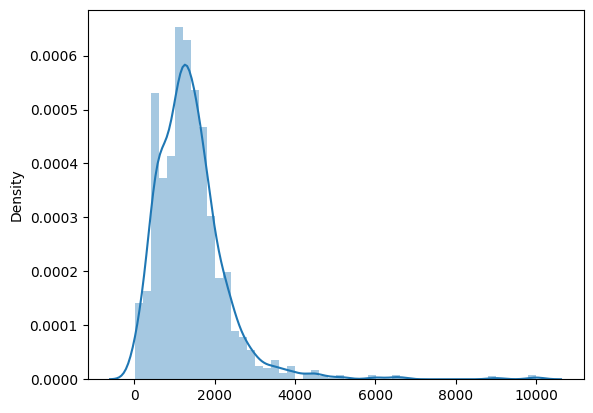

In [62]:
sns.distplot(x=df['carpet_area'])

<Axes: xlabel='carpet_area'>

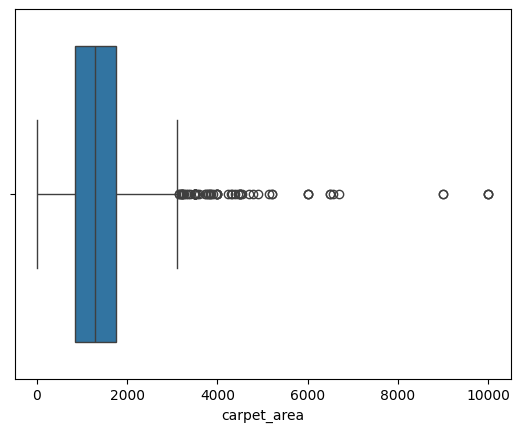

In [63]:
sns.boxplot(x=df['carpet_area'])

### Luxury_score

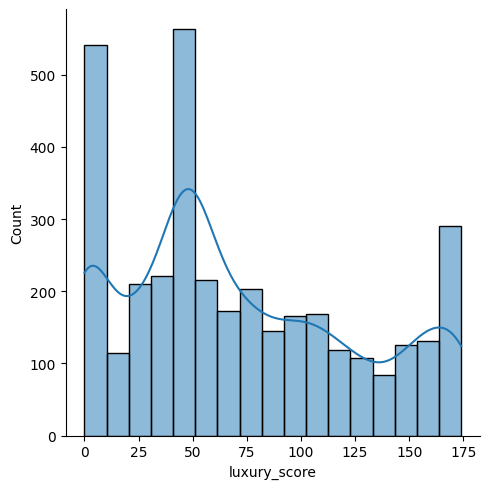

In [65]:
sns.displot(df['luxury_score'],kde=True)

<Axes: ylabel='luxury_score'>

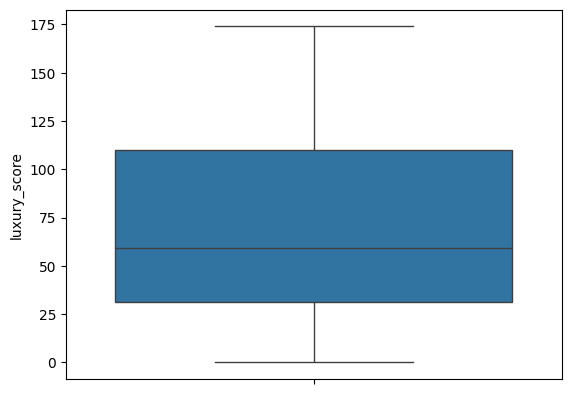

In [66]:
sns.boxplot(df['luxury_score'])

C:\Users\8429s\AppData\Local\Temp\ipykernel_6252\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

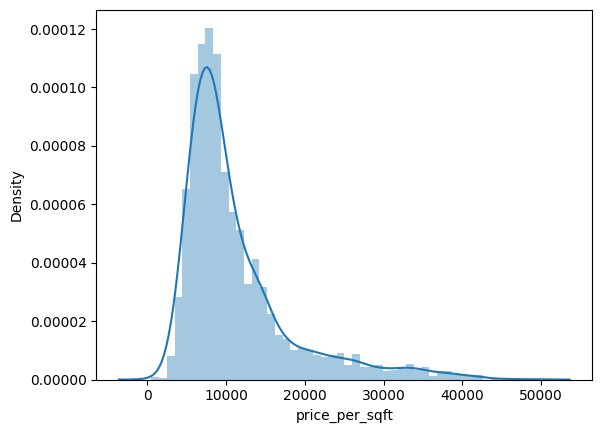

In [68]:
sns.distplot(df['price_per_sqft'])

<Axes: ylabel='price_per_sqft'>

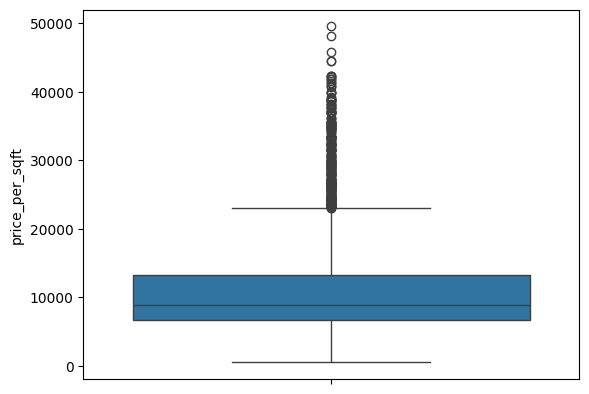

In [69]:
sns.boxplot(df['price_per_sqft'])

In [70]:
df[df['price_per_sqft'] > 42000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
259,house,independent,sector 26,20.0,44444.0,4500.0,Plot area 500(418.06 sq.m.),5,7,3+,3.0,West,Relatively New,NaN,4500.0,NaN,0,1,0,1,0,0,97
849,house,sushant lok 1 builder floors,sector 43,13.0,48148.0,2700.0,Plot area 300(250.84 sq.m.),3,3,3+,4.0,North,New Property,NaN,2700.0,NaN,0,0,0,1,0,2,7
968,house,independent,sector 25,13.0,45710.0,2844.0,Plot area 316(264.22 sq.m.),6,8,3+,NaN,NaN,Relatively New,NaN,2844.0,NaN,1,1,1,1,0,0,0
1221,house,independent,sector 26,19.0,42222.0,4500.0,Plot area 500(418.06 sq.m.),6,8,3+,3.0,East,Moderately Old,NaN,4500.0,NaN,1,1,1,1,0,2,103
1391,house,independent,sector 105,9.9,49500.0,2000.0,Built Up area: 2000 (185.81 sq.m.)Carpet area:...,2,2,2,3.0,North,Undefined,NaN,2000.0,1800.0,0,0,0,0,0,1,0
1474,house,independent,sector 28,12.0,42194.0,2844.0,Plot area 316(264.22 sq.m.),4,5,3+,4.0,East,Relatively New,NaN,2844.0,NaN,0,1,1,1,0,2,60
1701,house,independent,sector 55,5.0,44444.0,1125.0,Plot area 125(104.52 sq.m.)Built Up area: 115 ...,9,9,3+,5.0,East,New Property,NaN,115.0,100.0,0,0,0,0,1,2,44
2642,house,dlf city plots,sector 26,19.0,42054.0,4518.0,Plot area 502(419.74 sq.m.),6,6,3,2.0,East,Relatively New,NaN,4518.0,NaN,1,1,0,0,0,2,121
3365,house,independent,sector 43,9.5,42222.0,2250.0,Plot area 302(252.51 sq.m.)Built Up area: 300 ...,5,5,3+,2.0,North-East,Relatively New,NaN,300.0,250.0,0,1,0,1,0,2,88


In [72]:
x = df[df['price_per_sqft'] <= 20000]
(x['area']/x['bedRoom']).quantile(0.05)

np.float64(251.60000000000002)

In [74]:
df[(df['area']/df['bedRoom'])<250]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
8,flat,signature global solera,sector 107,0.28,5828.0,480.0,Carpet area: 489 (45.43 sq.m.),2,2,2,11.0,South,Relatively New,NaN,NaN,489.0,0,0,0,0,0,1,45
18,house,my home,sector 110,0.34,12592.0,270.0,Plot area 270(25.08 sq.m.),2,2,2,3.0,West,Moderately Old,NaN,270.0,NaN,0,0,0,0,0,1,22
33,flat,gls arawali homes,sohna road,0.28,5982.0,468.0,Carpet area: 468 (43.48 sq.m.),2,2,2,3.0,NaN,Relatively New,NaN,NaN,468.0,0,0,0,0,0,1,42
59,house,not applicable,sector 4,0.75,11718.0,640.0,Plot area 640(59.46 sq.m.),5,4,3,2.0,NaN,Moderately Old,NaN,640.0,NaN,0,0,0,0,0,1,0
63,house,independent,sector 7,1.20,11194.0,1072.0,Built Up area: 1072 (99.59 sq.m.),5,4,2,3.0,NaN,Undefined,NaN,1072.0,NaN,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3619,flat,pyramid urban homes 2,sector 86,0.41,8283.0,495.0,Carpet area: 501 (46.54 sq.m.),2,2,1,7.0,West,New Property,NaN,NaN,501.0,1,1,0,1,1,1,49
3635,house,ss omnia,sector 86,0.42,9333.0,450.0,Plot area 50(4.65 sq.m.),5,3,2,3.0,NaN,Relatively New,NaN,50.0,NaN,0,0,0,0,0,1,0
3678,flat,signature global solera,sector 107,0.28,5828.0,480.0,Carpet area: 489 (45.43 sq.m.),2,2,2,NaN,North-East,Relatively New,NaN,NaN,489.0,0,0,0,0,0,1,45
3753,house,independent,sector 10a,3.60,19608.0,1836.0,Plot area 204(170.57 sq.m.),8,4,3,3.0,North,Moderately Old,NaN,1836.0,NaN,0,0,0,1,0,2,28


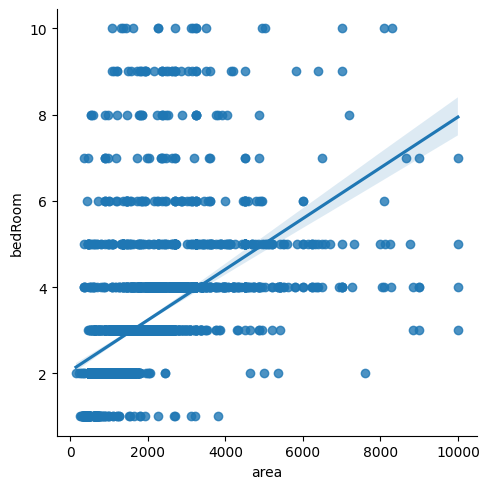

In [75]:
sns.lmplot(data=df,x='area',y='bedRoom')

In [76]:
df['area_room_ratio']=df['area']/df['bedRoom']

In [77]:
(df[df['area_room_ratio']<250])['bedRoom'].value_counts()

bedRoom
2     47
3     33
5     28
6     17
4     17
9     15
8     12
7      8
10     7
Name: count, dtype: int64

In [78]:
df=df[df['area_room_ratio']>100]

In [79]:
outliers_df=df[df['area_room_ratio']<250 &(df['bedRoom']>3)]

In [81]:
outliers_df['bedRoom'] = round(outliers_df['bedRoom']/outliers_df['floorNum'])

In [82]:
df.update(outliers_df)

In [83]:
df['area_room_ratio'] = df['area']/df['bedRoom']

In [85]:
df[(df['area_room_ratio']<250) & (df['bedRoom']>4)].shape

(72, 24)

In [86]:
df=df[~((df['area_room_ratio']<250) & (df['bedRoom']>4))]

In [87]:
df.shape

(3485, 24)

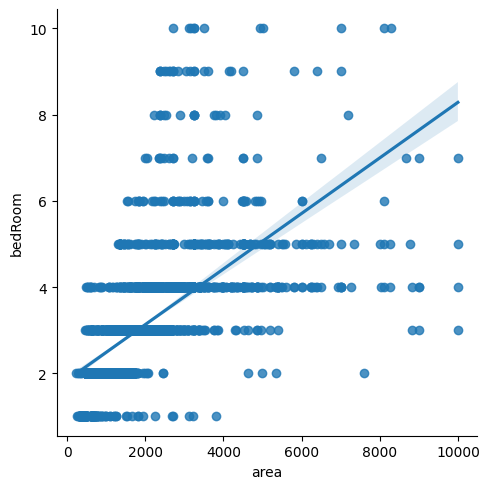

In [88]:
sns.lmplot(data=df,x='area',y='bedRoom')

In [89]:
df.head(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,house,independent,sector 4,0.58,9619.0,603.0,Plot area 67(6.22 sq.m.),2,2,1,2.0,West,Moderately Old,NaN,67.0,NaN,0,0,0,1,1,1,7,301.500000
1,flat,emaar mgf palm hills,sector 77,1.25,8620.0,1450.0,Super Built up area 1450(134.71 sq.m.)Carpet a...,3,4,3,3.0,North,Relatively New,1450.0,NaN,1177.0,1,1,0,0,0,1,49,483.333333
2,flat,chd avenue,sector 71,1.00,6734.0,1485.0,Super Built up area 1485(137.96 sq.m.),3,3,3+,3.0,North,Relatively New,1485.0,NaN,NaN,0,0,0,0,0,2,7,495.000000
3,flat,ild grand,sector 37c,1.20,6593.0,1820.0,Super Built up area 1820(169.08 sq.m.),3,3,3,7.0,NaN,Under Construction,1820.0,NaN,NaN,0,0,0,0,0,1,24,606.666667
4,flat,dlf the ultima,sector 81,2.20,10461.0,2103.0,Super Built up area 2103(195.38 sq.m.)Built Up...,3,3,3+,5.0,East,Relatively New,2103.0,1570.0,1257.0,1,1,0,1,1,0,49,701.000000


In [90]:
df.to_csv('C:/Users/8429s/OneDrive/Desktop/Placement/Projects/Real Estate Price Prediction and Recommendation System/Data_Clean/flats_and_house_outlier_remove.csv',index=False)